# The Effects of Iran War Risk on Global Financial Markets (2026)

This notebook replicates Rigobon & Sack (2003), *"The Effects of War Risk on U.S. Financial Markets"*, using their heteroskedasticity-based identification method (Rigobon 2003, *"Identification through Heteroskedasticity"*) on the 2026 Iran war. The main change from the original paper: the H/L "war news" day classification comes out of an NLP pipeline run over GDELT-indexed news, instead of being picked by hand from press commentary.

Two normalizing-variable specifications are reported, the **2-year Treasury yield** (primary, matches the original paper) and **Brent crude** (secondary experiment, motivated by the war's oil-supply-shock transmission channel).

See `README.md` for the full methodology and `AI_USE.md` for the AI-use disclosure.


In [1]:
import sys
sys.path.insert(0, '../src')
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display

from config import DATA_PROCESSED, DATA_RAW, NORMALIZING_VARIABLES_TO_RUN, ANALYSIS_START, ANALYSIS_END
pd.set_option('display.max_columns', None)

## 1. Corpus statistics and NLP evaluation

In [2]:
articles = pd.read_parquet(DATA_RAW / 'gdelt_articles.parquet')
print(f"{len(articles)} articles, {articles['date'].nunique()} distinct days, "
      f"{articles['date'].min()} to {articles['date'].max()}")
articles['domain'].value_counts().head(15)

3750 articles, 16 distinct days, 2026-02-28 to 2026-09-12


domain
finance.yahoo.com               47
gdnonline.com                   41
arabherald.com                  40
economictimes.indiatimes.com    37
news.webindia123.com            32
iranherald.com                  29
yahoo.com                       26
jpost.com                       26
newkerala.com                   24
middleeaststar.com              24
timesofindia.indiatimes.com     24
hindustantimes.com              20
deccanchronicle.com             18
middleeasteye.net               18
heraldglobe.com                 17
Name: count, dtype: int64

In [3]:
with open(DATA_PROCESSED / 'nlp_eval_report.json') as f:
    nlp_eval = json.load(f)
nlp_eval

{'status': 'ok',
 'n_labeled': 180,
 'tp': 28,
 'fp': 0,
 'fn': 61,
 'tn': 91,
 'precision': 1.0,
 'recall': 0.3146067415730337,
 'inter_method_correlation': {'lexicon': {'lexicon': 1.0,
   'tone': 0.561,
   'finbert': 0.585},
  'tone': {'lexicon': 0.561, 'tone': 1.0, 'finbert': 0.79},
  'finbert': {'lexicon': 0.585, 'tone': 0.79, 'finbert': 1.0}}}

A quick read on this: high precision, low recall basically means the lexicon filter is picky, when it says an article is relevant it usually is, but it misses a lot of genuinely relevant articles that just don't use its exact vocabulary (more on this below, with a concrete example).

### What vocabulary is the relevance filter actually missing

Looking only at false negatives that already contain the word "iran" but still got no relevance-term hit, so this is not just re-showing the missing-the-word-iran problem above, this is genuinely missed vocabulary.

In [4]:
import sys
sys.path.insert(0, '../src/eval')
from analyze_false_negatives import main as analyze_false_negatives
top_terms, fn_summary = analyze_false_negatives()
fn_summary

False negatives: 61 total (39 missing 'iran' entirely, 22 have 'iran' but no relevance term)

Top 20 missed terms (bucket 2, 'iran' present but no relevance-term hit):
     term  count                                                                                        example_headline
      oil      3                                 Shipping and Oil Prices at Risk as US – Israel – Iran Tensions Escalate
   israel      3                                 Shipping and Oil Prices at Risk as US – Israel – Iran Tensions Escalate
    trump      3                        Trump sending envoys Witkoff , Kushner to Pakistan for fresh Iran talks : Report
    warns      3                                Iran uses detentions as leverage : Human rights advocate warns Americans
   prices      2                                 Shipping and Oil Prices at Risk as US – Israel – Iran Tensions Escalate
      air      2                             Tens of thousands of air travelers stranded worldwide after s

{'n_false_negatives': 61,
 'n_bucket1_no_iran_token': 39,
 'n_bucket2_has_iran_no_relevance_term': 22}

A term above being new-war-specific (a fresh operation codename, a new sanctions program, a new weapons system) means even an updated, general-purpose NLP tool would likely miss it too, it's not something our hand-built list did wrong specifically. A term being generic (a place name, a diplomacy word) just means our narrow list happened to skip something a slightly broader list would have caught, an easy fix.

## 2. Figure 1: Iran war-risk news intensity timeline

The composite intensity score below combines GDELT's own news volume with three NLP scores (lexicon, TF-IDF tone, FinBERT), each z-scored and summed with fixed weights:

$$I_t = 0.30\,z(vol_{pct}) + 0.20\,z(vol_{raw}) + 0.15\,z(lex) + 0.15\,z(tone) + 0.20\,z(finbert)$$

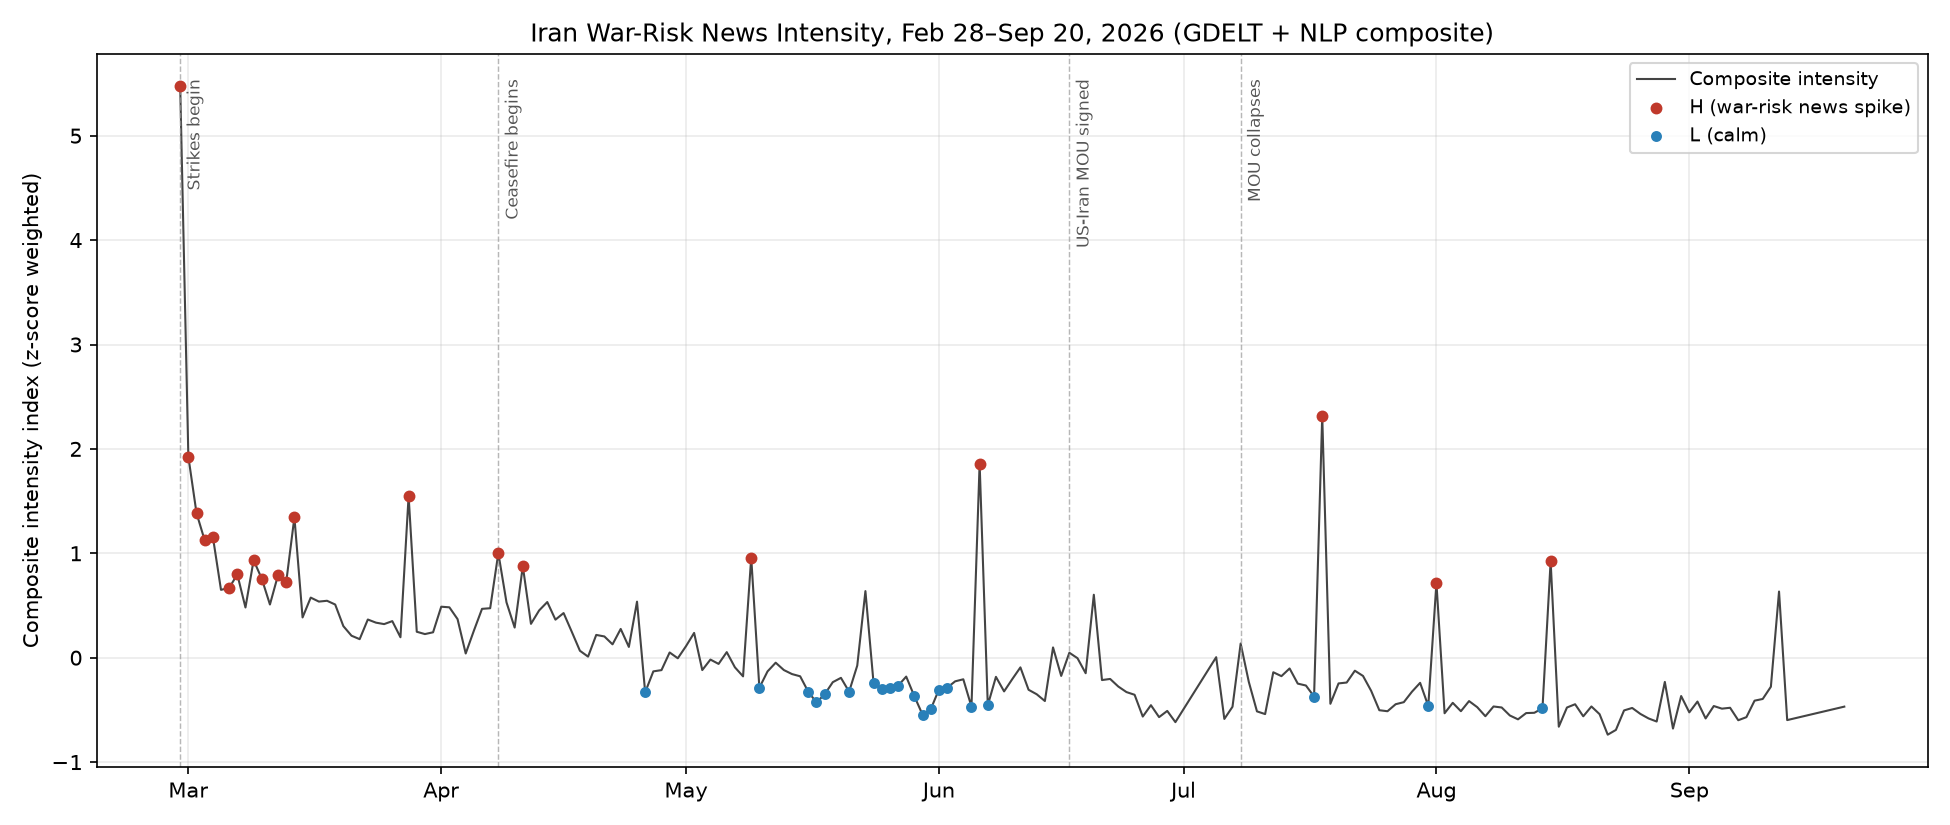

In [5]:
display(Image('figure1_intensity_timeline.png'))

### A possible explanation for some visible counterintuitive results

2026-04-08, the day the ceasefire begins, still comes out as an H-day (top decile intensity) rather than calm, and that's not a bug. The composite index measures news-driven variance and attention, not direction, so a sudden ceasefire announcement is itself a big, uncertain, breaking-news event and can spike the index just as a sudden attack would. It also isn't a clean "good news" day even on the ground, the independently-verified war timeline (see `IRAN_WAR_TIMELINE` in `config.py`, checked against Wikipedia/Britannica/House of Commons Library sources during planning, not derived from the sparse article sample) records that Israel resumed strikes on Lebanon that same day, so the theatre widened right as the US-Iran ceasefire took hold.

This actually fits the identification strategy rather than breaking it. Rigobon & Sack only need elevated variance on H-days, not a particular sign of news, so a high-uncertainty day with a ceasefire in one theatre and fresh strikes in another is a fair H-day even though it looks odd at first glance.

## 3. Table 1: H/L regime dates

In [6]:
table1 = pd.read_csv(DATA_PROCESSED / 'table1_regime_dates.csv')
table1

,date,composite_intensity,direction,is_H,is_L,confound_flag
0,2026-02-28,5.472209,Unclear,True,False,False
1,2026-03-01,1.925138,Increased,True,False,False
2,2026-03-02,1.384723,Decreased,True,False,False
3,2026-03-03,1.124467,Decreased,True,False,False
4,2026-03-04,1.159993,Decreased,True,False,False
5,2026-03-06,0.668182,Decreased,True,False,False
6,2026-03-07,0.797587,Increased,True,False,False
7,2026-03-09,0.933726,Unclear,True,False,False
8,2026-03-10,0.756388,Decreased,True,False,False
9,2026-03-12,0.792961,Increased,True,False,False


Regime is H (top decile intensity, a war-news day) or L (a matched calm day picked close to an H-day, following the same logic as the original paper). Confound flag marks a day that also happens to be an FOMC date, we keep it in the sample and just flag it rather than dropping it, so it can be checked instead of hidden.

## 4. Results by normalizing variable

For every other variable $x_j$ we get three estimates of the same war-risk sensitivity coefficient $d$, all from the same $\Omega_H$ and $\Omega_L$ matrices:

$$\hat{d}=\Delta\Omega_{22}/\Delta\Omega_{21}\ \ (Eq.6) \qquad \hat{d}=\Delta\Omega_{21}/\Delta\Omega_{11}\ \ (Eq.7)$$

plus the IV versions ($\omega_1$, $\omega_2$, $\omega_3$, the last one is the two-instrument overidentified specification with a Sargan/J test). If the model actually fits a given variable, all of these should land close to each other, if they don't, that's a warning sign (see the dedicated Eq(10) section further down).


In [7]:
results = {}
for nv in NORMALIZING_VARIABLES_TO_RUN:
    results[nv] = {
        'table2': pd.read_parquet(DATA_PROCESSED / f'table2_estimates_{nv}.parquet'),
        'table3': pd.read_parquet(DATA_PROCESSED / f'table3_variance_decomp_{nv}.parquet'),
    }
print(f"Primary normalizing variable: {NORMALIZING_VARIABLES_TO_RUN[0]}")
results[NORMALIZING_VARIABLES_TO_RUN[0]]['table2']

Primary normalizing variable: treasury_2y


,variable,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat,iv_w1_pvalue,iv_w2_coef,iv_w2_tstat,iv_w2_pvalue,iv_w3_coef,iv_w3_tstat,iv_w3_pvalue,iv_w3_sargan_stat,iv_w3_sargan_pvalue,bootstrap_mean,bootstrap_se,bootstrap_ci_low,bootstrap_ci_high,n_obs
0,brent_oil,273.502112,307.635561,147.010074,0.725444,0.468180,306.724347,1.680618,0.092837,245.919277,1.378243,0.168128,0.540409,0.462263,-33.936150,1593.330997,-1037.561832,1131.442179,26
1,wti_oil,359.015731,310.645239,144.887833,0.707150,0.479473,388.182518,1.545301,0.122273,282.832038,1.262341,0.206826,0.819119,0.365438,-59.556864,1868.350580,-1125.417574,1114.845920,26
2,gold,4373.695330,1549.673292,357.685334,0.175736,0.860501,9888.752160,0.239785,0.810497,1613.941849,0.656618,0.511427,1.304965,0.253308,-1411.957105,8645.243665,-15960.571954,7696.955549,26
3,dollar_index,-123.037749,-2.073355,2.133071,0.330289,0.741182,91.266157,0.182258,0.855380,-2.919437,-0.254329,0.799241,6.302394,0.012058,2.466795,42.391519,-44.608269,46.709235,26
4,vix,-144.217898,-45.287311,2.843476,0.045474,0.963730,973.696839,0.079116,0.936940,-35.119942,-0.392082,0.694998,2.130314,0.144411,32.854614,207.668887,-288.903581,377.667095,26
5,sp500,5398.999853,506.725209,-29.819515,-0.013730,0.989046,-9057.518083,-0.174640,0.861363,717.235639,0.301808,0.762798,1.274278,0.258966,-1450.991173,8470.295119,-14785.388218,8737.894107,26
6,em_equity,-13.899594,31.444264,3.990385,0.074270,0.940796,-290.507161,-0.053030,0.957708,14.899555,0.406539,0.684347,0.346701,0.555987,-33.791645,159.335107,-344.235629,151.362700,26
7,israel_equity,46.218829,58.561797,3.997558,0.065683,0.947630,224.658735,0.169927,0.865068,38.003053,0.779424,0.435730,0.907042,0.340901,-30.285065,174.562174,-400.229125,225.605584,26
8,treasury_10y,1.110825,1.557962,0.891551,1.432224,0.152080,1.112637,1.714844,0.086374,0.994796,1.552179,0.120619,0.371993,0.541920,0.492900,4.283061,-4.036670,5.009589,26
9,breakeven_10y,-0.546903,0.541107,0.398487,0.731967,0.464189,0.152991,0.186056,0.852401,0.306682,0.858408,0.390667,0.202269,0.652895,0.000142,2.463447,-2.472594,2.726637,26


A few things worth looking at in this table: Eq(6) and Eq(7) only agree if the model's assumptions hold for that variable, so a big gap between them is itself informative. Look at the IV t-stats, not just the coefficients, before trusting a number. Sargan p-value below 0.05 means omega1 and omega3 disagree more than chance would explain, a soft sign the identifying assumption is shaky for that variable.

### Comparison to Rigobon & Sack (2003): Iraq 2003 vs. Iran 2026 (treasury_2y run only)

In [8]:
comp_path = DATA_PROCESSED / 'table2_comparison.html'
if comp_path.exists():
    with open(comp_path) as f:
        display(HTML(f.read()))

Variable,Iraq 2003 coef,Iraq 2003 t-stat,Iran 2026 coef,Iran 2026 t-stat,Same direction?
brent_oil,-,-,147.010,0.725,New variable (no 2003 analog)
wti_oil,0.770,2.440,144.888,0.707,Yes
gold,1.300,0.260,357.685,0.176,Yes
dollar_index,-0.440,2.220,2.133,0.330,No
vix,-,-,2.843,0.045,New variable (no 2003 analog)
sp500,-3.760,2.900,-29.820,-0.014,Yes
em_equity,-,-,3.990,0.074,New variable (no 2003 analog)
israel_equity,-,-,3.998,0.066,New variable (no 2003 analog)
treasury_10y,-0.260,11.850,0.892,1.432,No
breakeven_10y,-0.110,3.450,0.398,0.732,No


Same direction just checks if the sign matches the 2003 Iraq result. A "No" is not automatically wrong, the two wars are different (oil shock vs. flight to safety, more on this in the Discussion), it's just flagged so it isn't missed.

In [9]:
print(f"Secondary normalizing variable: {NORMALIZING_VARIABLES_TO_RUN[1]}")
results[NORMALIZING_VARIABLES_TO_RUN[1]]['table2']

Secondary normalizing variable: brent_oil


,variable,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat,iv_w1_pvalue,iv_w2_coef,iv_w2_tstat,iv_w2_pvalue,iv_w3_coef,iv_w3_tstat,iv_w3_pvalue,iv_w3_sargan_stat,iv_w3_sargan_pvalue,bootstrap_mean,bootstrap_se,bootstrap_ci_low,bootstrap_ci_high,n_obs
0,wti_oil,1.188581,1.115198,1.101146,11.849262,0.000000e+00,1.174245,14.973683,0.000000e+00,1.138505,13.369063,0.000000e+00,17.965661,0.000022,1.144534,1.143814,0.787024,1.347742,26
1,gold,-9.290784,-8.670399,-7.698403,-2.609712,9.061835e-03,-12.652966,-1.284045,1.991264e-01,-8.376757,-2.872644,4.070525e-03,0.847416,0.357284,-10.539394,51.686883,-22.974800,3.288116,26
2,dollar_index,0.066143,0.045838,0.041384,3.061981,2.198772e-03,0.080492,1.843025,6.532542e-02,0.048066,3.494058,4.757382e-04,2.011267,0.156135,0.084310,0.814784,0.014275,0.189952,26
3,vix,0.236053,0.328843,0.303210,3.012401,2.591896e-03,0.367733,1.184537,2.362007e-01,0.311933,3.188678,1.429250e-03,0.190516,0.662488,0.503642,3.801142,0.019182,0.953473,26
4,sp500,-3.296842,-9.862579,-8.603606,-2.569533,1.018356e-02,-7.358934,-0.784492,4.327517e-01,-8.436306,-2.916259,3.542568e-03,0.077919,0.780137,-13.438869,80.419627,-27.360927,3.823297,26
5,em_equity,0.030834,-0.168469,-0.144138,-2.509500,1.209024e-02,-0.093984,-0.324974,7.452006e-01,-0.138603,-2.387808,1.694921e-02,0.196889,0.657244,-0.270394,2.319273,-0.528807,0.024039,26
6,israel_equity,-0.160667,-0.200220,-0.178712,-1.789257,7.357336e-02,-0.342522,-0.946299,3.439959e-01,-0.190052,-2.090989,3.652902e-02,0.919025,0.337731,-0.319020,2.934762,-0.652831,0.124706,26
7,treasury_2y,0.003251,0.003656,0.003260,1.680618,9.283706e-02,0.006802,0.725444,4.681796e-01,0.003479,1.678338,9.328116e-02,0.476267,0.490118,0.007706,0.081336,-0.001497,0.017781,26
8,treasury_10y,0.008392,0.002451,0.002359,1.478085,1.393850e-01,0.009422,0.937559,3.484713e-01,0.002378,1.493612,1.352770e-01,1.523200,0.217136,0.006062,0.081873,-0.003539,0.011261,26
9,breakeven_10y,-0.002359,0.001491,0.001751,2.434097,1.492901e-02,0.000753,0.212831,8.314590e-01,0.001864,2.849710,4.375917e-03,0.511975,0.474285,0.000705,0.016155,-0.004125,0.003323,26


## 5. Extension: splitting H-days into bad vs. good war news

**Read the N columns before anything else here.** These splits are small groups on top of an already-small H set, so treat every coefficient below as a rough signal, not something to lean on the way the main Table 2 numbers above can be leaned on, same spirit as flagging the treasury_2y weak-identification result instead of hiding it.

"Bad" (war risk escalating) and "good" (war risk de-escalating) come from the `direction` column already used in Table 1, built off GDELT's own day-over-day tone change, so it exists for every day, not just the ones with article-level text. The same Eq(6)/(7) and IV machinery from Table 2 is reused as-is, just on these smaller subsets.

### Checking the brief's exact hypothesis directly

The brief's own stated expectation: bad war news means yields and oil up, equities down, good war news the reverse. This is a different, more direct check than the IV coefficients further down, it just looks at the raw average daily change in each variable by regime, no normalizing variable involved at all.

In [10]:
panel = pd.read_parquet(DATA_PROCESSED / 'master_panel_filtered.parquet')
is_bad = panel['is_H'] & (panel['direction'] == 'Increased')
is_good = panel['is_H'] & (panel['direction'] == 'Decreased')
is_l = panel['is_L']
print(f"bad-news H-days: {int(is_bad.sum())}, good-news H-days: {int(is_good.sum())}, L-days: {int(is_l.sum())}")

check_vars = {'brent_oil': 'oil', 'treasury_2y': '2yr yield', 'treasury_10y': '10yr yield',
              'bbb_spread': 'BBB spread', 'hy_spread': 'HY spread', 'sp500': 'S&P 500',
              'em_equity': 'EM equities', 'israel_equity': 'Israel equities', 'vix': 'VIX'}
rows = []
for var, label in check_vars.items():
    col = f'd_{var}'
    rows.append({'Variable': label, 'Mean d, bad news': panel.loc[is_bad, col].mean(),
                  'Mean d, good news': panel.loc[is_good, col].mean(), 'Mean d, calm (L)': panel.loc[is_l, col].mean()})
hyp_table = pd.DataFrame(rows)
hyp_table

bad-news H-days: 5, good-news H-days: 10, L-days: 16


,Variable,"Mean d, bad news","Mean d, good news","Mean d, calm (L)"
0,oil,3.568001,-2.384443,0.493333
1,2yr yield,0.030000,-0.007778,0.020000
2,10yr yield,0.030000,-0.011111,0.021667
3,BBB spread,0.004000,-0.005000,-0.000625
4,HY spread,0.004894,-0.033591,-0.002614
5,S&P 500,-2.468066,17.864421,-13.189250
6,EM equities,0.002267,0.295673,-0.232330
7,Israel equities,-0.759053,-0.229880,-0.416714
8,VIX,0.617470,-0.168956,0.258426


In [11]:
expect_up_on_bad = {'brent_oil', 'treasury_2y', 'treasury_10y', 'bbb_spread', 'hy_spread'}
expect_down_on_bad = {'sp500', 'em_equity', 'israel_equity'}
hits, checked = 0, 0
for var in expect_up_on_bad | expect_down_on_bad:
    bad_mean = panel.loc[is_bad, f'd_{var}'].mean()
    checked += 1
    if (var in expect_up_on_bad and bad_mean > 0) or (var in expect_down_on_bad and bad_mean < 0):
        hits += 1
print(f'Matches the briefs stated bad-news direction on {hits}/{checked} of the variables it names directly')

Matches the briefs stated bad-news direction on 7/8 of the variables it names directly


On bad news: oil and both yields move up, both credit spreads widen, the S&P 500 falls, matching the brief's stated expectation on most of the variables it names directly. On good news the pattern mostly reverses, oil and yields fall, spreads narrow, and the S&P 500 rises sharply, a clean, if small-sample, confirmation that direction of news matters in the way the brief expects.

Not everything lines up (Israel equities fall on both bad and good news here, EM equities barely move on bad news), and n=5 bad-news days is genuinely thin, so read this as a real, directionally-consistent signal, not a settled result.

In [12]:
import sys
sys.path.insert(0, '../src')
from three_regime_analysis import main as run_three_regime

three_regime_results = {}
for nv in NORMALIZING_VARIABLES_TO_RUN:
    three_regime_results[nv] = run_three_regime(nv)

[treasury_2y] three-regime split: bad-news H-days=5, good-news H-days=10, L-days=16


  bad_vs_L: saved -> /Users/aditya/Documents/NYU/Sem-3/FRE-GY 7871 (NLP)/Assignment_3/data/processed/table_three_regime_bad_vs_L_treasury_2y.parquet


  good_vs_L: saved -> /Users/aditya/Documents/NYU/Sem-3/FRE-GY 7871 (NLP)/Assignment_3/data/processed/table_three_regime_good_vs_L_treasury_2y.parquet


  bad_vs_good: saved -> /Users/aditya/Documents/NYU/Sem-3/FRE-GY 7871 (NLP)/Assignment_3/data/processed/table_three_regime_bad_vs_good_treasury_2y.parquet
[brent_oil] three-regime split: bad-news H-days=5, good-news H-days=10, L-days=16


  bad_vs_L: saved -> /Users/aditya/Documents/NYU/Sem-3/FRE-GY 7871 (NLP)/Assignment_3/data/processed/table_three_regime_bad_vs_L_brent_oil.parquet


  good_vs_L: saved -> /Users/aditya/Documents/NYU/Sem-3/FRE-GY 7871 (NLP)/Assignment_3/data/processed/table_three_regime_good_vs_L_brent_oil.parquet


  bad_vs_good: saved -> /Users/aditya/Documents/NYU/Sem-3/FRE-GY 7871 (NLP)/Assignment_3/data/processed/table_three_regime_bad_vs_good_brent_oil.parquet


In [13]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    for pair in ['bad_vs_L', 'good_vs_L', 'bad_vs_good']:
        print(f'--- {nv}: {pair} ---')
        display(three_regime_results[nv][pair][['variable', 'n_pos', 'n_neg', 'eq6_direct', 'eq7_direct', 'iv_w1_coef', 'iv_w1_tstat']])

--- treasury_2y: bad_vs_L ---


,variable,n_pos,n_neg,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat
0,brent_oil,5,16,11.305685,70.695163,2007.373905,0.039132
1,wti_oil,5,16,17.806106,87.182869,2146.782398,0.039097
2,gold,5,16,-6793.128388,190.900995,14054.355621,0.036509
3,dollar_index,5,16,2.622804,4.572195,16.750240,0.057833
4,vix,5,16,-59.875865,14.631703,-283.834386,-0.033804
5,sp500,5,16,165.270547,-896.236432,11473.506165,0.034564
6,em_equity,5,16,37.083186,-10.396443,367.633867,0.035880
7,israel_equity,5,16,-4.429193,-18.197067,142.722750,0.030986
8,treasury_10y,5,16,-0.472895,0.326185,-1.968750,-0.031052
9,breakeven_10y,5,16,-1.100826,0.136569,5.625000,0.039209


--- treasury_2y: good_vs_L ---


,variable,n_pos,n_neg,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat
0,brent_oil,10,16,606.931374,-181.072378,-43.756888,-0.618697
1,wti_oil,10,16,1032.534330,-166.113771,-41.534066,-0.621731
2,gold,10,16,10049.356795,-1559.663202,-1024.567992,-0.857921
3,dollar_index,10,16,-31.816228,9.986524,6.073352,1.087661
4,vix,10,16,-169.825377,89.465331,51.002871,1.777143
5,sp500,10,16,4178.617579,-1846.649374,-1330.794777,-1.302710
6,em_equity,10,16,33.919486,-52.002891,-33.351658,-1.469376
7,israel_equity,10,16,51.132761,-130.848067,-59.129157,-1.279545
8,treasury_10y,10,16,1.918281,-1.364046,0.054961,0.060072
9,breakeven_10y,10,16,3.766234,0.024807,0.045720,0.253060


--- treasury_2y: bad_vs_good ---


...

,variable,n_pos,n_neg,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat
0,wti_oil,5,16,1.378630,1.408854,0.455815,0.040835
1,gold,5,16,25.321726,-64.076406,-244.478712,-0.049926
2,dollar_index,5,16,0.035519,0.422422,2.004515,0.050474
3,vix,5,16,-0.404216,2.711731,7.602143,0.051430
4,sp500,5,16,2.068762,-89.582023,-129.798541,-0.053166
5,em_equity,5,16,0.208857,-2.309541,-4.059040,-0.051542
6,israel_equity,5,16,-0.035750,-2.820744,-7.012463,-0.051334
7,treasury_2y,5,16,0.014145,0.088451,0.264306,0.051269
8,treasury_10y,5,16,-0.025240,0.007646,0.026688,0.056600
9,breakeven_10y,5,16,0.026959,-0.006977,-0.027406,-0.045021


--- brent_oil: good_vs_L ---


,variable,n_pos,n_neg,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat
0,wti_oil,10,16,1.276698,1.222447,1.217631,12.803496
1,gold,10,16,-18.757025,-7.603496,-8.402473,-1.599623
2,dollar_index,10,16,0.083476,0.034635,0.039092,1.904264
3,vix,10,16,0.330329,0.418522,0.426144,2.940871
4,sp500,10,16,-6.152646,-11.412041,-12.283000,-2.623314
5,em_equity,10,16,-0.085717,-0.187248,-0.204607,-2.335180
6,israel_equity,10,16,-0.342467,-0.177769,-0.184227,-1.313453
7,treasury_2y,10,16,-0.005523,0.001648,0.002514,1.381417
8,treasury_10y,10,16,0.013800,0.001725,0.002466,1.307477
9,breakeven_10y,10,16,-0.000384,0.002216,0.001909,1.907357


--- brent_oil: bad_vs_good ---


,variable,n_pos,n_neg,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat
0,wti_oil,5,10,1.272111,1.215211,1.216449,13.283695
1,gold,5,10,-39.016841,-5.411406,-5.612922,-1.095473
2,dollar_index,5,10,0.123633,0.019582,0.021421,1.048550
3,vix,5,10,0.564978,0.329508,0.355439,2.843268
4,sp500,5,10,-9.565034,-8.377743,-9.238044,-2.632727
5,em_equity,5,10,-0.337541,-0.104868,-0.132938,-1.755420
6,israel_equity,5,10,-0.789181,-0.075178,-0.113484,-0.856356
7,treasury_2y,5,10,0.033697,-0.001722,-0.000581,-0.230127
8,treasury_10y,5,10,0.021548,0.001496,0.001319,0.706178
9,breakeven_10y,5,10,0.002495,0.002573,0.002604,3.667608


bad_vs_L and good_vs_L answer: does the direction of the news matter for the size or sign of the market reaction, or does any high-variance war-news day move markets about the same regardless of whether the news itself was good or bad. bad_vs_good is the most direct version of that question, comparing the two escalation directions to each other instead of each to calm days separately. If a variable's coefficient flips sign between bad_vs_L and good_vs_L, that's actually informative (direction matters), it's only a problem if the flip looks like pure noise given how few days are behind it.

## 6. Table 3: Variance decomposition (both normalizing variables)

In [14]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    print(f"--- {nv} ---")
    display(results[nv]['table3'])

--- treasury_2y ---


,variable,var_L,var_H,predicted_delta_var,pct_explained_H_days,pct_explained_all_days
0,brent_oil,7.562890,40.087066,8.354169,0.208401,0.470128
1,wti_oil,7.002626,50.113543,8.114708,0.161926,0.501235
2,gold,3104.745962,5724.724642,49.455130,0.008639,0.008352
3,dollar_index,0.062351,0.160961,0.001759,0.010927,0.016182
4,vix,3.821084,7.027711,0.003125,0.000445,0.001264
5,sp500,4375.689708,5433.225095,0.343724,0.000063,0.000089
6,em_equity,2.066932,1.897984,0.006155,0.003243,0.004183
7,israel_equity,3.045593,4.091859,0.006177,0.001510,0.001648
8,treasury_10y,0.001161,0.001830,0.000307,0.167938,0.154951
9,breakeven_10y,0.000473,0.000358,0.000061,0.171297,0.125108


--- brent_oil ---


,variable,var_L,var_H,predicted_delta_var,pct_explained_H_days,pct_explained_all_days
0,wti_oil,7.002626,50.113543,39.436317,0.786939,2.435932
1,gold,3104.745962,5724.724642,1927.558757,0.336708,0.325514
2,dollar_index,0.062351,0.160961,0.055701,0.346053,0.512476
3,vix,3.821084,7.027711,2.990150,0.425480,1.209100
4,sp500,4375.689708,5433.225095,2407.505920,0.443108,0.623856
5,em_equity,2.066932,1.897984,0.675716,0.356018,0.459257
6,israel_equity,3.045593,4.091859,1.038755,0.253859,0.277094
7,treasury_2y,0.001636,0.002023,0.000346,0.170896,0.140751
8,treasury_10y,0.001161,0.001830,0.000181,0.098964,0.091310
9,breakeven_10y,0.000473,0.000358,0.000100,0.278434,0.203356


Values above 100% do show up here, that's a flag for a noisy or weak estimate for that variable, not a literal claim that war risk explains more than all the variance in it.

## 7. Robustness checks

In [15]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    print(f"--- {nv}: first-half vs second-half coefficient stability ---")
    display(pd.read_parquet(DATA_PROCESSED / f'robustness_stability_{nv}.parquet'))

--- treasury_2y: first-half vs second-half coefficient stability ---


,variable,status,coef_first_half,coef_second_half,stability_z,stability_pvalue
0,brent_oil,ok,55.448350,-40.885326,3.331766,0.000863
1,wti_oil,ok,55.542953,-41.488942,3.087118,0.002021
2,gold,ok,-438.730488,-1541.163510,2.551879,0.010714
3,dollar_index,ok,3.368170,4.921742,-0.520837,0.602481
4,vix,ok,25.400067,48.327293,-1.450923,0.146801
5,sp500,ok,-734.691720,-1464.110946,1.188946,0.234461
6,em_equity,ok,-18.835392,-47.672878,2.701098,0.006911
7,israel_equity,ok,-13.628856,-33.755413,0.997341,0.318599
8,treasury_10y,ok,0.761791,0.423729,1.233139,0.217524
9,breakeven_10y,ok,0.212780,-0.112125,2.521386,0.011689


--- brent_oil: first-half vs second-half coefficient stability ---


,variable,status,coef_first_half,coef_second_half,stability_z,stability_pvalue
0,wti_oil,ok,1.137659,0.515446,1.827659,0.067601
1,gold,ok,-7.641463,-9.769644,0.092260,0.926492
2,dollar_index,ok,0.042010,0.049808,-0.068527,0.945366
3,vix,ok,0.309294,0.428857,-0.162383,0.871004
4,sp500,ok,-7.381557,-36.644415,0.820890,0.411709
5,em_equity,ok,-0.147132,-0.203971,0.110989,0.911625
6,israel_equity,ok,-0.154600,-0.711354,0.558860,0.576257
7,treasury_2y,ok,0.002816,0.016898,-0.728722,0.466172
8,treasury_10y,ok,0.001415,0.025957,-0.916906,0.359192
9,breakeven_10y,ok,0.001997,0.000043,0.490442,0.623821


In [16]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    sens = pd.read_parquet(DATA_PROCESSED / f'robustness_threshold_sensitivity_{nv}.parquet')
    print(f"--- {nv}: H/L threshold sensitivity ---")
    if not sens.empty:
        display(sens.pivot(index='variable', columns='H_quantile', values='coef'))

--- treasury_2y: H/L threshold sensitivity ---


H_quantile,0.85,0.90,0.95
variable,,,
bbb_spread,-0.024846,0.297872,0.039461
breakeven_10y,0.490062,0.327660,0.080847
brent_oil,128.664280,221.222180,-31.118400
broad_dollar,0.717786,-2.280809,8.321906
dollar_index,6.111962,5.378322,4.565384
em_equity,-9.071934,5.330070,-39.230927
gold,9.981515,217.907156,-1084.690139
hy_spread,0.113391,0.678645,0.284628
israel_equity,6.138428,24.196184,-47.659550


--- brent_oil: H/L threshold sensitivity ---


H_quantile,0.85,0.90,0.95
variable,,,
bbb_spread,0.001281,0.001870,0.002125
breakeven_10y,0.002496,0.001181,0.016319
broad_dollar,0.069051,0.095986,-0.213683
dollar_index,0.052448,0.056877,-0.227357
em_equity,-0.156768,-0.181533,0.044357
gold,-4.084583,-11.697860,26.839461
hy_spread,0.010370,0.012866,-0.016339
israel_equity,-0.123657,-0.219667,0.896191
sp500,-7.564260,-7.496950,-12.127962


Stability splits the war into two halves and re-estimates in each, a coefficient that jumps around a lot between halves shouldn't be trusted much (the war's phases were pretty different, initial strikes vs. later ceasefire-and-collapse). Threshold sensitivity redoes the whole H/L split at three different cutoffs, small movement means the result doesn't depend on us picking exactly the top decile as H.

## 8. Eq(10): does the paper's own equivalence actually hold here?

The paper (Rigobon & Sack 2003, p.6) writes the $\omega_1$ IV estimator as a closed form and says it's identical to Eq(7):

$$\hat{d}=\frac{Cov_H(\Delta x_1,\Delta x_2)-Cov_L(\Delta x_1,\Delta x_2)}{Var_H(\Delta x_1)-Var_L(\Delta x_1)}\ \ (Eq.10)$$

That equivalence is only exact if $\Delta x$ has zero mean (the paper says this outright in its own footnote 2), which real market data won't do exactly. Eq(7) here is a plain covariance ratio (de-means within each regime), the IV version (`iv_w1_coef` in Table 2) is a real pooled 2SLS regression with an intercept, so the two can drift apart whenever the H-day and L-day means of the normalizing variable aren't close relative to its own spread.

In [17]:
panel = pd.read_parquet(DATA_PROCESSED / 'master_panel_filtered.parquet')
rows = []
for nv in NORMALIZING_VARIABLES_TO_RUN:
    h = panel.loc[panel['is_H'], f'd_{nv}'].dropna()
    l = panel.loc[panel['is_L'], f'd_{nv}'].dropna()
    rows.append({'normalizing_variable': nv, 'mean_d_on_H': h.mean(), 'mean_d_on_L': l.mean(),
                 'std_d_all_days': panel[f'd_{nv}'].std()})
pd.DataFrame(rows)

,normalizing_variable,mean_d_on_H,mean_d_on_L,std_d_all_days
0,treasury_2y,0.003125,0.020000,0.049560
1,brent_oil,0.333126,0.493333,4.215446


2-year Treasury yield changes are tiny to begin with, so even a small difference between its H-day and L-day mean is large relative to its own variance, and Eq(7) vs. the IV omega1 estimate pull apart a lot for several variables below. Brent crude's day-to-day moves are much bigger, so the same kind of mean difference barely matters and the two estimates stay close, which is what the paper's own algebra predicts when its assumptions are closer to holding.

In [18]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    t2 = results[nv]['table2'][['variable', 'eq7_direct', 'iv_w1_coef']].copy()
    t2['ratio_iv_over_eq7'] = t2['iv_w1_coef'] / t2['eq7_direct']
    print(f'--- {nv}: Eq(7) vs. IV omega1 ---')
    display(t2)

--- treasury_2y: Eq(7) vs. IV omega1 ---


,variable,eq7_direct,iv_w1_coef,ratio_iv_over_eq7
0,brent_oil,307.635561,147.010074,0.477871
1,wti_oil,310.645239,144.887833,0.466409
2,gold,1549.673292,357.685334,0.230813
3,dollar_index,-2.073355,2.133071,-1.028802
4,vix,-45.287311,2.843476,-0.062787
5,sp500,506.725209,-29.819515,-0.058848
6,em_equity,31.444264,3.990385,0.126903
7,israel_equity,58.561797,3.997558,0.068262
8,treasury_10y,1.557962,0.891551,0.572255
9,breakeven_10y,0.541107,0.398487,0.736428


--- brent_oil: Eq(7) vs. IV omega1 ---


,variable,eq7_direct,iv_w1_coef,ratio_iv_over_eq7
0,wti_oil,1.115198,1.101146,0.987400
1,gold,-8.670399,-7.698403,0.887895
2,dollar_index,0.045838,0.041384,0.902817
3,vix,0.328843,0.303210,0.922050
4,sp500,-9.862579,-8.603606,0.872349
5,em_equity,-0.168469,-0.144138,0.855575
6,israel_equity,-0.200220,-0.178712,0.892576
7,treasury_2y,0.003656,0.003260,0.891687
8,treasury_10y,0.002451,0.002359,0.962691
9,breakeven_10y,0.001491,0.001751,1.174855


`ratio_iv_over_eq7` close to 1.0 is good, it means the IV route and the closed-form route agree the way the paper says they should. For `treasury_2y` a few variables (dollar_index, broad_dollar, vix) have ratios wildly away from 1.0, on top of the weak-identification evidence Figure 2 already shows. For `brent_oil` almost every ratio sits reasonably close to 1.0, gold is the one exception, which lines up with gold being the odd result flagged in the Discussion.

## 9. Figure 3: raw variance and covariance on war-news vs. calm days

Everything above comes out of $\Omega_H$ and $\Omega_L$, the covariance matrices of daily changes computed separately on H-days and L-days:

$$\Omega \equiv E\left([\Delta x_1\ \Delta x_2]'\,[\Delta x_1\ \Delta x_2]\right)$$

This figure just plots those raw numbers directly instead of a ratio or a t-stat, so we can see what's actually feeding the estimator.

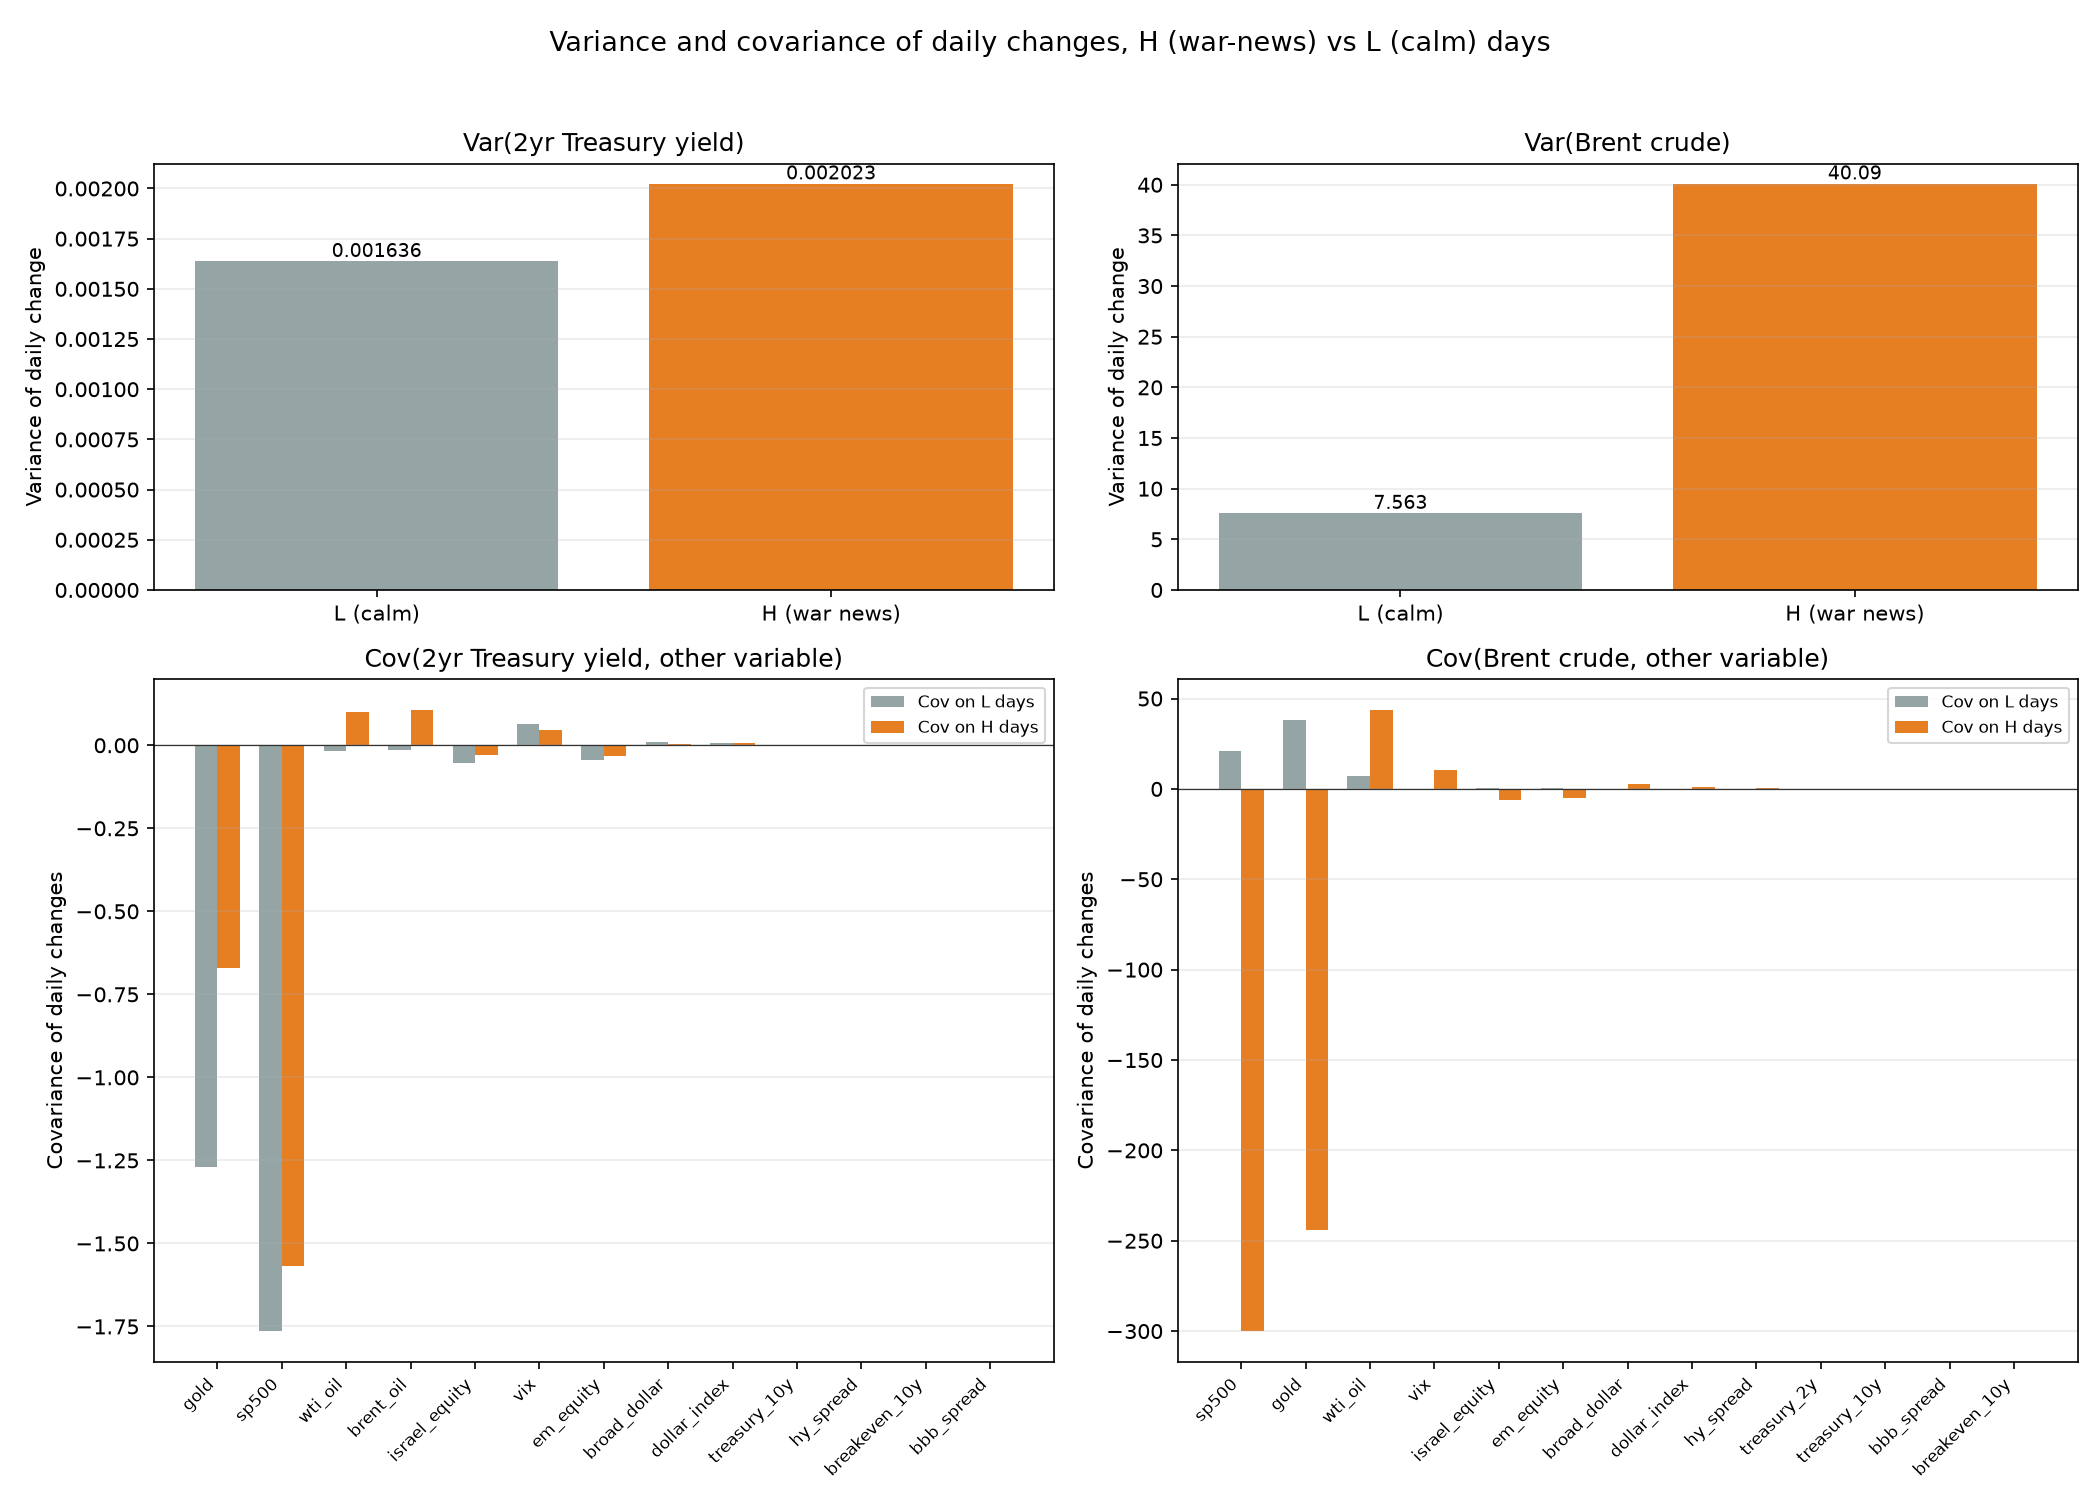

In [19]:
display(Image('figure3_var_covar.png'))

Top row: the normalizing variable's own variance on L-days vs. H-days, Brent oil's jumps about 11x on war-news days, the Treasury yield's barely moves, same identification gap Figure 2 shows, here in raw units. Bottom row: covariance with every other variable, H-days vs. L-days, S&P 500 and gold dominate the y-axis in both panels purely because they're large, unstandardized numbers, not because they're the most "explained" variables (Table 2/3's ratios already correct for that scale difference).

## 10. Figure 2: why Brent oil identifies the model better than the 2yr Treasury yield

(a) the identification condition itself, a normalizing variable's own variance should jump on war-news days; (b) |t-statistics| for every other variable's sensitivity under each normalizing-variable choice; (c) a scale-free instability score (swing across three alternative H-day thresholds) computed for every variable, not just one example.

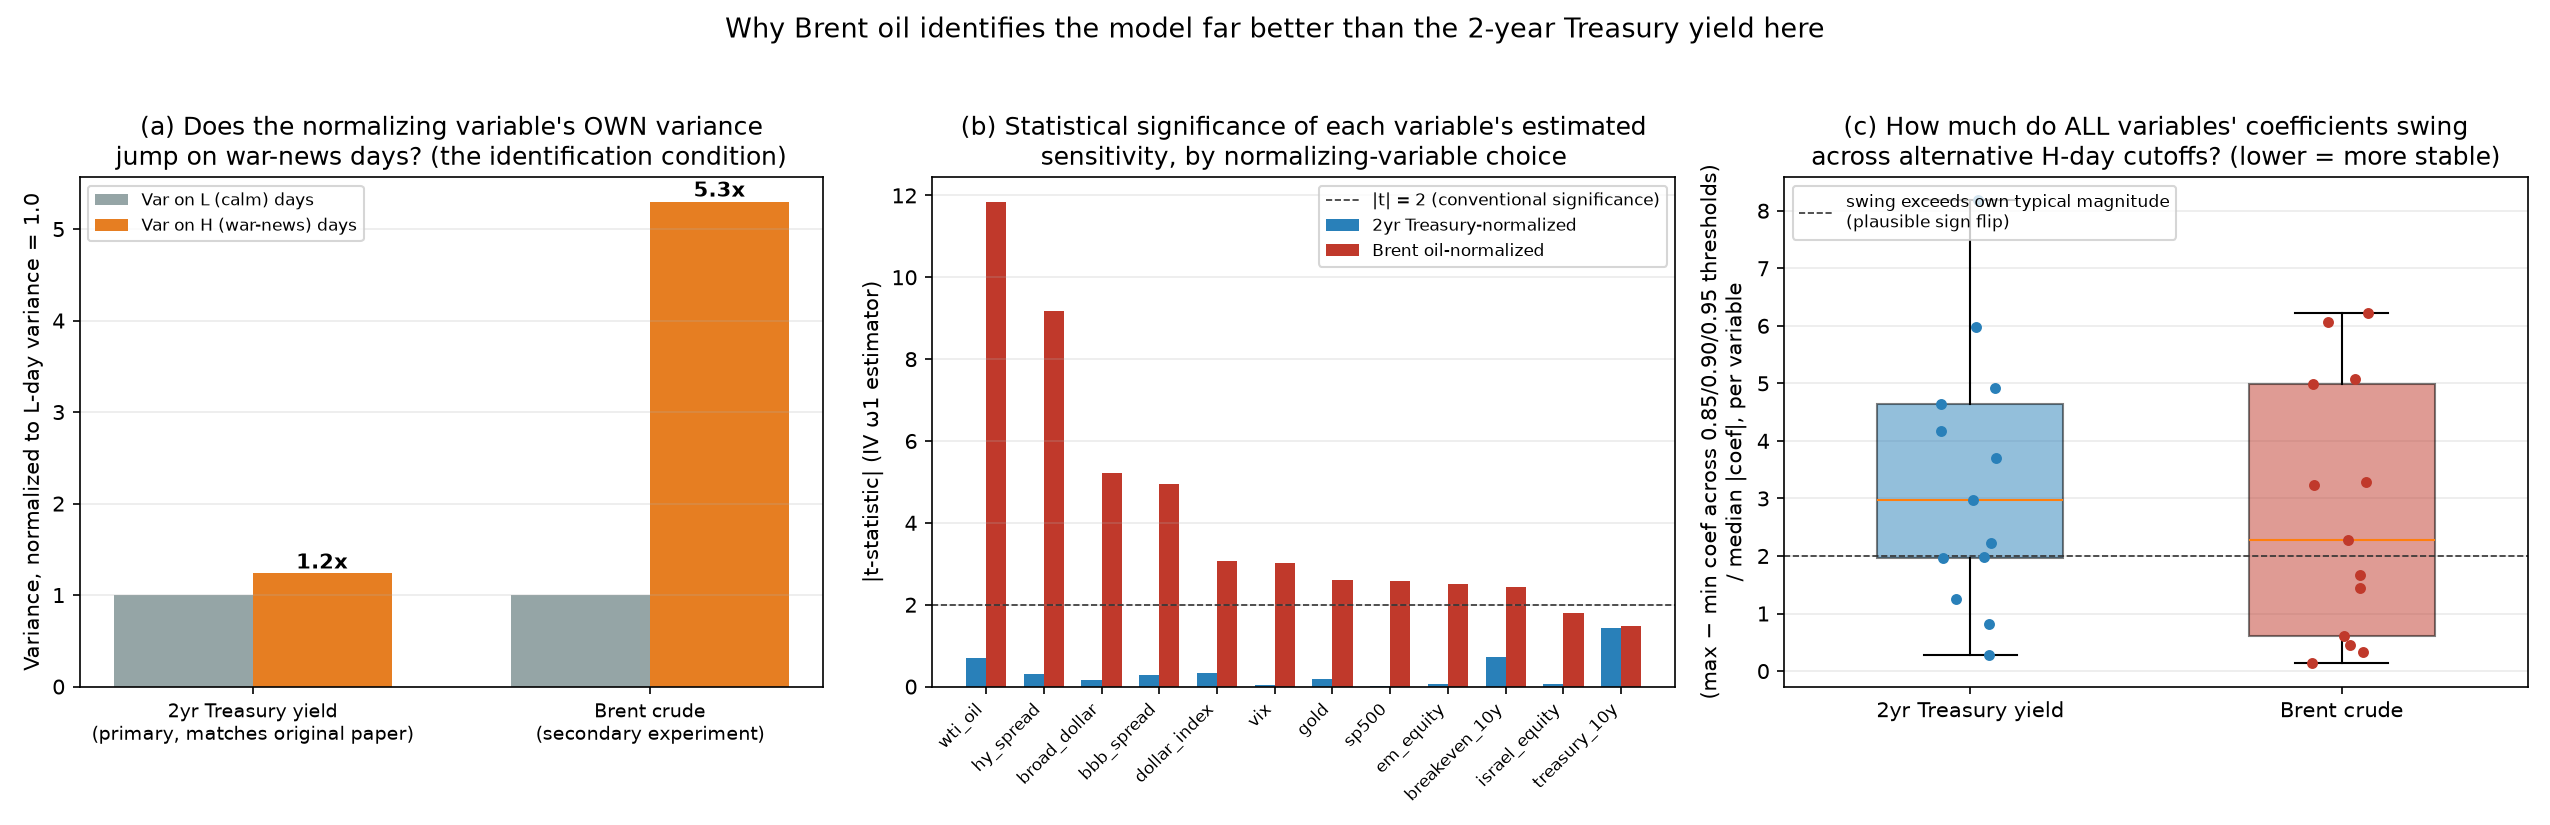

In [20]:
display(Image('figure2_oil_vs_treasury.png'))

Read panel (a) first, it's the actual precondition for everything else. If the normalizing variable's own variance doesn't jump on H-days, none of the downstream coefficients for that choice can be trusted much.

## 11. The assumption on "non-war" effects, and what our results say about it

The whole method rests on one assumption (Rigobon & Sack 2003, p.5): only the variance of the war-risk factor $z_1$ changes between H-days and L-days. Everything else (monetary policy news, other macro data, unrelated shocks) is assumed to keep the same variance in both sets of days, that's what lets us blame the entire change in $\Omega$ on war risk alone:

$$\Delta\Omega_{11}=\Delta\sigma^2(z_1) \qquad \Delta\Omega_{21}=\hat{d}\cdot\Delta\sigma^2(z_1) \qquad \Delta\Omega_{22}=\hat{d}^2\cdot\Delta\sigma^2(z_1)$$

We can't verify this directly since $z_1$ is unobserved by design, but we can look for cracks in it.

In [21]:
n_h, n_l = int(panel['is_H'].sum()), int(panel['is_L'].sum())
n_confound_h = int((panel['is_H'] & panel['confound_flag']).sum())
n_confound_l = int((panel['is_L'] & panel['confound_flag']).sum())
sargan_counts = {nv: int((results[nv]['table2']['iv_w3_sargan_pvalue'] < 0.05).sum()) for nv in NORMALIZING_VARIABLES_TO_RUN}
print(f"H-days: {n_h} (confound-flagged: {n_confound_h}), L-days: {n_l} (confound-flagged: {n_confound_l})")
print('Sargan rejections at 5%:', sargan_counts)

H-days: 18 (confound-flagged: 0), L-days: 16 (confound-flagged: 0)
Sargan rejections at 5%: {'treasury_2y': 3, 'brent_oil': 2}


Looking at the counts printed just above: the obvious, known confound (Fed meetings) is basically not contaminating the H set, which is good, but this only covers confounds we thought to list in advance. The Eq(6) vs. Eq(7) disagreement from section 8 is really a live test of the same assumption, if some other factor's variance also moved on our H-days, $\Delta\Omega$ stops having the clean shape the assumption predicts. Same story with the Sargan rejections above, more rejections means more variables where omega1 and omega2 aren't telling a consistent story.

**What this predicts, put simply:** treasury_2y is more likely picking up a mix of war risk and other macro noise (rate expectations, Fed-adjacent moves not on our confound calendar), since the 2-year yield reacts to a lot more than just war risk day to day. Brent oil is a more direct, single-channel bet (Hormuz disruption to physical oil supply), so there are fewer other big factors competing to move its variance on the same days, and the assumption ends up closer to true for it. Same conclusion Figure 2 already points to, from a completely different angle.

## 12. Discussion

**Data.** GDELT-indexed articles across the analysis window (see corpus stats above), the NLP relevance filter (lexicon) was evaluated against a Claude-judged reference set (disclosed in `AI_USE.md`), picky but accurate, missing many genuinely relevant articles (diplomatic talks, oil-market commentary) that don't use its specific escalation vocabulary. The three article-level NLP scores agree reasonably well with each other (TF-IDF tone and FinBERT correlate strongly, both correlate more loosely with the pure-keyword lexicon), the expected pattern for methods using genuinely different mechanisms.

**Two normalizing-variable specifications tell different stories.** The primary specification (2-year Treasury yield, matching Rigobon & Sack 2003 exactly) is *weakly identified*, the yield's own variance is not clearly elevated on H-days in this sample, unlike Iraq 2003 where it was roughly 6x higher on war-news days. Figure 2 makes this concrete, the yield's own H/L variance ratio is much smaller than oil's, which shows up as low |t-statistics| across nearly every other variable and as coefficient swings across alternative H-day thresholds that approach or exceed the "plausible sign flip" boundary. The secondary specification (Brent crude, motivated by the war's Strait-of-Hormuz/oil-supply character) is stable and statistically strong across nearly every variable.

**Economic interpretation.** Against the oil anchor, equities fall (S&P 500, Israel, EM), volatility and the dollar rise, credit spreads widen, all consistent with a classic risk-off shock. But Treasury yields and inflation breakevens *rise*, not fall, with war-risk-driven oil moves. That's the opposite mechanism from Iraq 2003, where war risk operated as a flight-to-safety shock (yields fell as investors sought duration and the outlook darkened). The 2026 Iran war instead looks like it transmits mainly as an **oil supply shock**, inflationary and hawkish for policy rates, which lines up with the war's actual character (a Strait of Hormuz disruption to global energy supply) far better than a generic "fear of war" story does.

**Why yields rise instead of fall, one more piece of context.** The US now produces roughly 13.8 million barrels of crude a day, against roughly 5.70 million in 2003 (EIA, checked live, see `config.py`'s `US_OIL_PRODUCTION_CONTEXT`). That's a genuinely different starting point for the US as an oil producer. A bigger domestic cushion plausibly weakens the flight-to-quality channel that dominated in 2003, a Hormuz shock now shows up more through inflation and rate expectations than through a pure safety bid for Treasuries. Offered as a plausible reason behind the pattern we already see, not a new claim the coefficients themselves prove on their own.

**A genuinely counterintuitive, robust result: gold falls.** A classic safe-haven story would predict gold *rising* alongside oil on war risk, but the coefficient is negative and consistently signed. One plausible reading, the broad dollar index rises strongly and significantly alongside oil in this episode, and dollar strength mechanically pressures dollar-denominated gold prices even when "fear" demand for gold might otherwise be rising, a currency effect dominating a safe-haven effect. Flagged as an open question rather than resolved.

**Robustness.** The first-half/second-half stability check does not reject coefficient stability for the Brent-oil specification (small samples per half limit power, so this is weak evidence of stability rather than strong evidence). The Sargan/J overidentification test rejects for a handful of variables (notably `wti_oil`, which is almost mechanically collinear with `brent_oil`, an expected instrument-strength artifact rather than a substantive concern) but not for the majority of variables. H/L threshold sensitivity shows the sign and rough order of magnitude are preserved for most Brent-oil-normalized coefficients, though point estimates aren't perfectly stable with a small H-day count to work with.

**Limitations** (see `report/report.pdf` for the full list, including a data-driven look at the identifying assumption itself): the confound calendar (FOMC dates) flags but does not exclude potentially contaminated days; each of the three NLP scoring methods has its own blind spots (the lexicon needs the literal word "iran" and misses relevant articles that don't use it); z-scoring the five composite components fixes their mean and variance but not their shape; the on-the-run Treasury liquidity premium from the original 9-variable set is deferred to Phase B; trading-calendar alignment across US/Gulf/Israeli market hours is an approximation; t-stats aren't corrected for multiple comparisons; and the GDELT artlist cap means article-level text only exists on a small fraction of days in this window (see the Limitations section in the PDF report for the exact count).

## 13. Is heteroskedasticity-based identification the best approach here?

Short answer: it's a reasonable primary choice for this project, but not obviously the only good one.

**Why it fits here.** We never have to sign or size any individual headline, which matters a lot given how mixed war coverage actually reads day to day (see the ceasefire-spike discussion under Figure 1). It also doesn't need an excluded instrument, which would be hard to defend for something as pervasive as war risk touching almost every market variable at once.

**Where it's weak.** The whole thing rests on one assumption we can't check directly (see section 11 above), and this notebook already has two independent pieces of evidence that it's cracking for the treasury_2y specification, the Eq(6)/Eq(7) disagreement and the Sargan rejections.

**Alternatives worth naming:**
- **Narrative event-study with hand-picked dates.** The original papers' own baseline approach. More interpretable, but brings back the subjective day-picking this whole NLP pipeline was built to remove.
- **A continuous text-based shock index as a direct regressor** (Baker-Bloom-Davis EPU style). Gives a signed, sized measure of war risk instead of a binary flag, but then the whole exercise depends on trusting that index to actually measure war risk correctly.
- **A market-priced instrument.** Something like Polymarket's war/ceasefire odds, continuous, real-time, priced by people with money on the outcome. See the report's identification-alternatives section for a direct check of how many Polymarket-mentioning articles actually sit in our own corpus.
- **GARCH or regime-switching directly on the financial series.** Models the variance shift structurally instead of assuming a clean two-bucket split, at the cost of real specification risk that heteroskedasticity ID avoids by construction.
- **Local projections or a structural VAR with sign restrictions.** Flexible on dynamics (this whole project is static, same-day only), but sign restrictions need exactly the kind of "which direction does war risk move things" assumption this project was trying to avoid needing.

**Our actual call:** keep heteroskedasticity ID as the primary method, it matches both reference papers and the assignment's own approach. But a Polymarket-odds instrument looks like the strongest, cheapest robustness cross-check to add. Checked, not assumed: an earlier corpus sample (before this window was rebased to Feb 28) did have real Polymarket-mentioning articles, this final corpus sample happens not to, see AI_USE.md and the report for the honest disclosure rather than reusing the old quote.

## 14. Where this analysis could be improved

- **Learn the relevance filter instead of hand-coding it.** Recall is only 0.31 because the lexicon needs the literal word "iran" plus a fixed term list (see the false-negative check in section 1 for concrete examples it misses, e.g. a headline about a CENTCOM aircraft crash in Iraq that never says "Iran"). We already have 180 Claude-judged labels sitting there, even a simple classifier (logistic regression on TF-IDF features) trained on those would likely beat the hand-built keyword rule.
- **Get a second, independent labeler for the eval set.** Right now relevance judgments are single-pass, from one LLM reading each headline once. A second human or model pass with an inter-annotator agreement score (Cohen's kappa) would tell us how much to trust precision/recall = 1.00/0.31 in the first place.
- **Full VAR pre-whitening instead of per-variable AR(1).** The original paper filters serial correlation with a VAR across all variables together, here we only remove each variable's own lag-1 autocorrelation. A full VAR would also catch cross-variable lead-lag effects (oil today predicting equities tomorrow), which the current AR(1) step can't see.
- **Robust scaling for the zero-inflated NLP components.** Lexicon, tone, and FinBERT are zero on about 92% of days then spike hard on the rest. A rank-based or median/IQR standardization would probably be less sensitive to those spikes than a mean/std z-score.
- **Test more than 2 normalizing variables, and pick with a rule, not by hand.** We ran treasury_2y (for comparability to 2003) and brent_oil (on a theory-driven hunch). A cleaner approach: compute the Var_H/Var_L ratio for every candidate variable up front and pick whichever clears some threshold, before looking at any downstream coefficients.
- **A placebo test on the H/L split itself.** Randomly relabel H/L many times (keeping the same counts) and see how often Eq(6)/Eq(7) agree, or Sargan rejects, by pure chance. That would turn today's "these numbers seem more stable for oil than for treasury" into an actual p-value.
- **Add the GSW liquidity premium (Phase B).** Already scoped in `liquidity_premium_gsw.py` but not run, this would bring the variable set fully in line with the original paper's 9 variables plus our 5 new ones.